In [2]:
import numpy as np
import os
dataset_path = "/kaggle/input/garbage-dataset/garbage_classification"
classes = os.listdir(dataset_path)
print (f"Classes found: {classes}")
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

Classes found: ['metal', 'Plastic-bag', 'white-glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'Bottle']


In [3]:
# Đảm bảo các thư viện phụ thuộc (dependencies) đã được cài đặt
!pip install torch torchvision torchaudio

# Đây là phương pháp cài đặt được khuyến nghị cho CLIP
!pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to /tmp/pip-req-build-pc55sytv
  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git /tmp/pip-req-build-pc55sytv
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369490 sha256=590d37acdccb4671ede651a77f43fe6ae49141137a25c493e7e77f703d81c7d3
  Stored in directory: /tmp/pip-ephem-wheel-cache-otzrwjkn/wheels/35/3e/df/3d24cbfb3b6a06f17a2bfd7d1138900d4365d9028aa8f6e92f
Successfully built clip


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import tensorflow as tf
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from skimage import feature
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import torch
from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize
import clip
import cv2
import numpy as np
from PIL import Image 

2026-01-19 13:50:39.219480: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768830639.438980      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768830639.502667      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768830640.016647      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768830640.016700      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768830640.016703      55 computation_placer.cc:177] computation placer alr

In [5]:
# Kích thước ảnh đầu vào mong muốn của CLIP (thường là 224x224)
CLIP_IMAGE_SIZE = 224 
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# Tải mô hình và tiền xử lý (ViT-B/32 là phiên bản phổ biến)
model, preprocess = clip.load("ViT-B/32", device=DEVICE)

# HÀM TRÍCH XUẤT ĐẶC TRƯNG CLIP
def compute_clip_features(image_path):
    """
    Trích xuất vector đặc trưng ảnh 512 chiều từ mô hình CLIP
    """
    try:
        # 1. Đọc ảnh (CV2) và chuyển sang PIL Image
        img_cv = cv2.imread(image_path)
        if img_cv is None:
            return None
        
        # Chuyển BGR (CV2) sang RGB
        img_rgb = cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB)
        img_pil = Image.fromarray(img_rgb)
        
        # 2. Tiền xử lý theo yêu cầu của CLIP
        image_input = preprocess(img_pil).unsqueeze(0).to(DEVICE)
        
        # 3. Trích xuất đặc trưng (Feature Extraction)
        with torch.no_grad():
            # Lấy vector đặc trưng ảnh (image features)
            image_features = model.encode_image(image_input)
            
        # 4. Chuẩn hóa và chuyển về NumPy (dạng vector 512 chiều)
        # Đặc trưng CLIP thường có kích thước 512 (với ViT-B/32)
        return image_features.cpu().numpy().flatten() 
    
    except Exception as e:
        print(f"Lỗi xử lý CLIP cho {image_path}: {e}")
        return None

# Tính đặc trưng CLIP cho tất cả ảnh
print("\nĐang tính CLIP features...")
clip_features_list = []
valid_labels = []
valid_image_paths = [] # Dùng lại danh sách này để chia dữ liệu

for idx, (img_path, label) in enumerate(zip(image_paths, labels)):
    if idx % 100 == 0:
        print(f"Đã xử lý {idx}/{len(image_paths)}")
    
    # *** THAY THẾ: Gọi hàm tính CLIP features ***
    clip_feat = compute_clip_features(img_path) 
    
    if clip_feat is not None:
        clip_features_list.append(clip_feat)
        valid_labels.append(label)
        valid_image_paths.append(img_path)

# Chuyển thành numpy array
X = np.array(clip_features_list)
y = np.array(valid_labels)

# Kích thước mới là 512 (đối với ViT-B/32)
print(f"\nCLIP features shape: {X.shape}") 
print(f"Labels shape: {y.shape}")
print(f"Số lượng class: {len(set(y))}")

100%|████████████████████████████████████████| 338M/338M [00:01<00:00, 238MiB/s]



Đang tính CLIP features...
Đã xử lý 0/15376
Đã xử lý 100/15376
Đã xử lý 200/15376
Đã xử lý 300/15376
Đã xử lý 400/15376
Đã xử lý 500/15376
Đã xử lý 600/15376
Đã xử lý 700/15376
Đã xử lý 800/15376
Đã xử lý 900/15376
Đã xử lý 1000/15376
Đã xử lý 1100/15376
Đã xử lý 1200/15376
Đã xử lý 1300/15376
Đã xử lý 1400/15376
Đã xử lý 1500/15376
Đã xử lý 1600/15376
Đã xử lý 1700/15376
Đã xử lý 1800/15376
Đã xử lý 1900/15376
Đã xử lý 2000/15376
Đã xử lý 2100/15376
Đã xử lý 2200/15376
Đã xử lý 2300/15376
Đã xử lý 2400/15376
Đã xử lý 2500/15376
Đã xử lý 2600/15376
Đã xử lý 2700/15376
Đã xử lý 2800/15376
Đã xử lý 2900/15376
Đã xử lý 3000/15376
Đã xử lý 3100/15376
Đã xử lý 3200/15376
Đã xử lý 3300/15376
Đã xử lý 3400/15376
Đã xử lý 3500/15376
Đã xử lý 3600/15376
Đã xử lý 3700/15376
Đã xử lý 3800/15376
Đã xử lý 3900/15376
Đã xử lý 4000/15376
Đã xử lý 4100/15376
Đã xử lý 4200/15376
Đã xử lý 4300/15376
Đã xử lý 4400/15376
Đã xử lý 4500/15376
Đã xử lý 4600/15376
Đã xử lý 4700/15376
Đã xử lý 4800/15376
Đã x

In [6]:
from sklearn.model_selection import train_test_split

TEST_SIZE_RATIO = 0.2  
VALID_SIZE_RATIO = 0.2 

# BƯỚC 1: CHIA TRAIN VÀ TẠM THỜI (TEMP)

temp_size = TEST_SIZE_RATIO + VALID_SIZE_RATIO 

X_train, X_temp, y_train, y_temp, paths_train, paths_temp = train_test_split(
    X, 
    y, 
    valid_image_paths, 
    test_size=temp_size, 
    random_state=42, 
    stratify=y
)

# BƯỚC 2: CHIA TẬP TẠM THỜI (TEMP) THÀNH VALID VÀ TEST

valid_test_ratio = TEST_SIZE_RATIO / temp_size 

X_valid, X_test, y_valid, y_test, paths_valid, paths_test = train_test_split(
    X_temp, 
    y_temp, 
    paths_temp,
    test_size=valid_test_ratio, # Chia tập Temp thành 50/50
    random_state=42, 
    stratify=y_temp # Stratify trên tập Temp
)

# KIỂM TRA KÍCH THƯỚC

print("KÍCH THƯỚC CÁC TẬP DỮ LIỆU:")
print(f"1. Tập Huấn luyện (Train) size: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]:.2%})")
print(f"2. Tập Thẩm định (Valid) size: {X_valid.shape[0]} ({X_valid.shape[0]/X.shape[0]:.2%})")
print(f"3. Tập Kiểm thử (Test) size: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]:.2%})")
print(f"Feature dimensions: {X_train.shape[1]}")

KÍCH THƯỚC CÁC TẬP DỮ LIỆU:
1. Tập Huấn luyện (Train) size: 9225 (60.00%)
2. Tập Thẩm định (Valid) size: 3075 (20.00%)
3. Tập Kiểm thử (Test) size: 3076 (20.01%)
Feature dimensions: 512


In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# --- THAM SỐ CỐ ĐỊNH BAN ĐẦU ---
FIXED_C = 1.0
FIXED_GAMMA = 'scale'

# HUẤN LUYỆN SVM VỚI THAM SỐ CỐ ĐỊNH

print(f"HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C={FIXED_C}, Gamma='{FIXED_GAMMA}')")

# Khởi tạo và huấn luyện mô hình trên tập TRAIN
fixed_svm_model = SVC(
    kernel='rbf',       
    C=FIXED_C,              
    gamma=FIXED_GAMMA,      
    random_state=42     
)

fixed_svm_model.fit(X_train, y_train)

print("Huấn luyện hoàn tất.")

HUẤN LUYỆN MÔ HÌNH SVM CƠ SỞ (C=1.0, Gamma='scale')
Huấn luyện hoàn tất.


In [8]:
# BƯỚC 2: ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP VALIDATION

# 1. Dự đoán trên tập Validation
y_pred_valid = fixed_svm_model.predict(X_valid)
valid_accuracy = accuracy_score(y_valid, y_pred_valid)
print(f"ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): {valid_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Thẩm định (Validation): 0.9876


In [9]:
# 2. Báo cáo Phân loại trên Validation
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nValidation (Classification Report):")
print(classification_report(y_valid, y_pred_valid, target_names=classes, labels=all_labels))
print("-" * 60)


Validation (Classification Report):
              precision    recall  f1-score   support

       metal       0.94      0.97      0.96       155
 Plastic-bag       1.00      0.99      1.00       142
 white-glass       0.99      0.96      0.97       155
  biological       0.99      1.00      0.99       197
       paper       0.98      0.99      0.98       211
     battery       0.99      0.99      0.99       189
       trash       1.00      0.99      1.00       140
   cardboard       0.97      0.98      0.97       178
       shoes       0.98      0.99      0.98       395
     clothes       1.00      0.99      0.99      1065
      Bottle       1.00      0.99      0.99       248

    accuracy                           0.99      3075
   macro avg       0.98      0.99      0.98      3075
weighted avg       0.99      0.99      0.99      3075

------------------------------------------------------------


In [10]:
# ĐÁNH GIÁ VÀ BÁO CÁO TRÊN TẬP TEST (Đánh giá cuối cùng)

# 1. Dự đoán trên tập Test
y_pred_test = fixed_svm_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): {test_accuracy:.4f}")

ĐỘ CHÍNH XÁC trên tập Kiểm thử (Test): 0.9883


In [11]:
# 2. Báo cáo Phân loại trên Test
print("\nTest (Classification Report):")
print(classification_report(y_test, y_pred_test, target_names=classes, labels=all_labels))


Test (Classification Report):
              precision    recall  f1-score   support

       metal       0.98      0.97      0.97       154
 Plastic-bag       1.00      0.99      1.00       142
 white-glass       0.97      0.99      0.98       155
  biological       0.98      0.99      0.98       197
       paper       0.98      0.97      0.97       212
     battery       0.99      0.99      0.99       189
       trash       0.97      1.00      0.99       139
   cardboard       0.98      0.97      0.97       178
       shoes       0.98      1.00      0.99       396
     clothes       1.00      0.99      1.00      1065
      Bottle       1.00      0.99      0.99       249

    accuracy                           0.99      3076
   macro avg       0.98      0.99      0.99      3076
weighted avg       0.99      0.99      0.99      3076



MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST


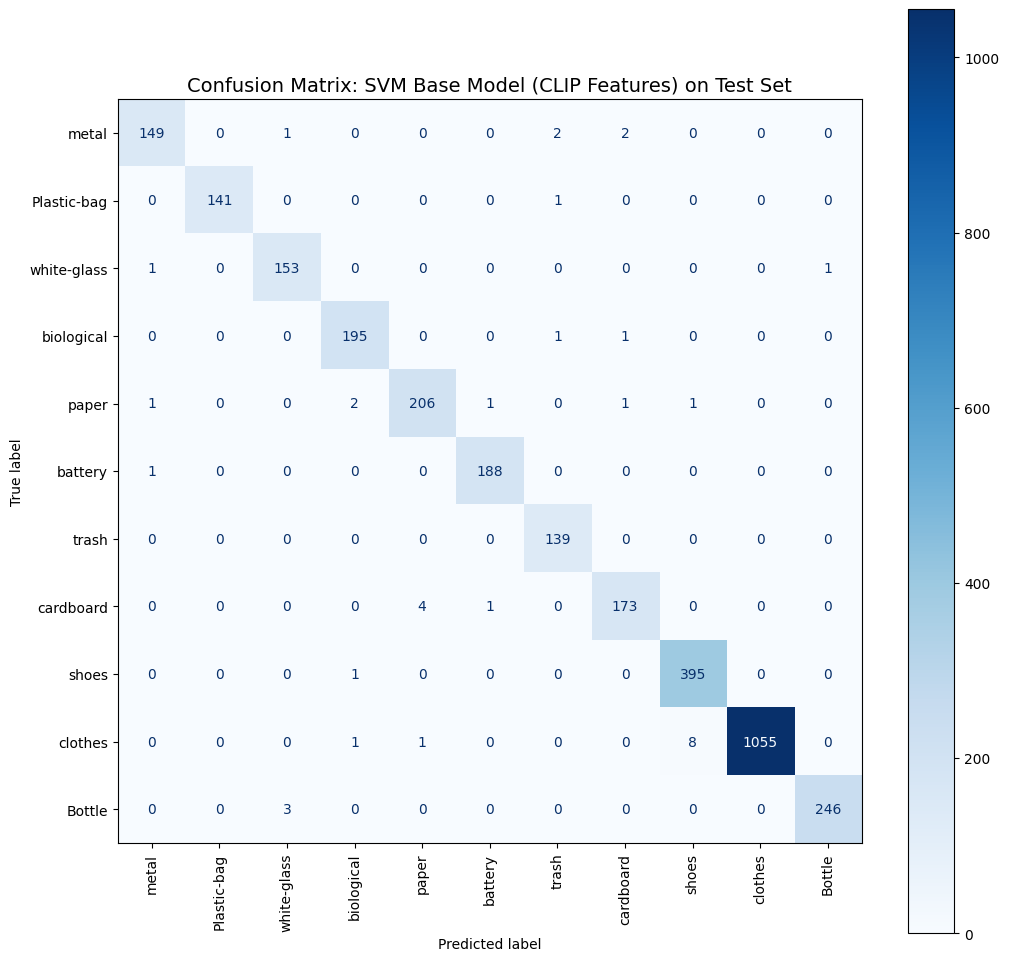


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_baseline_test.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_test, 
    labels=all_labels 
)

# 2. Trực quan hóa Ma trận nhầm lẫn

print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: SVM Base Model (CLIP Features) on Test Set', fontsize=14)


# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_baseline_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 3040 ảnh)


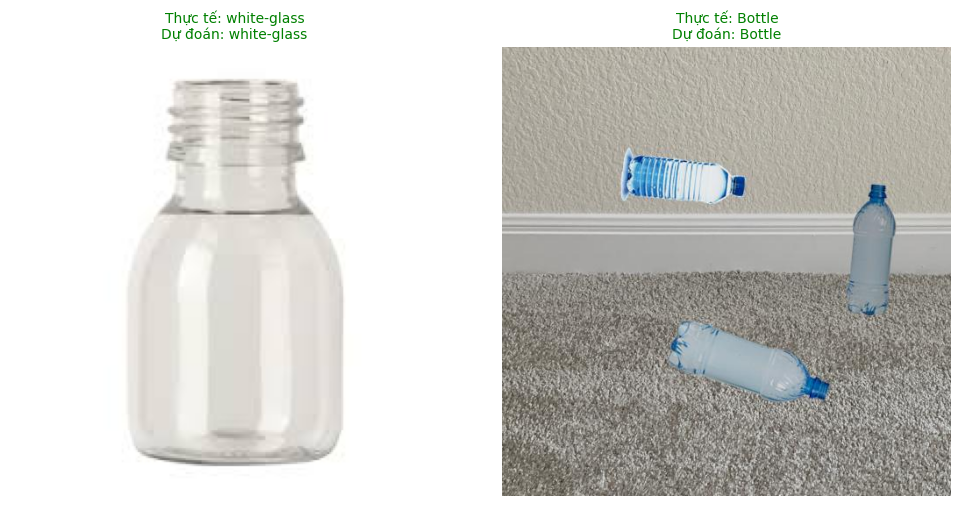

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

correctly_classified_mask = (y_test == y_pred_test)
indices_in_test_set = np.where(correctly_classified_mask)[0]
num_correctly_classified = len(indices_in_test_set)

print("="*60)
print(f"HIỂN THỊ 2 ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_correctly_classified} ảnh)")
print("="*60)

# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_correctly_classified) 

# *** LOGIC CHỌN VÀ HIỂN THỊ (ĐÃ SỬA LỖI return) ***

if num_correctly_classified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_correct_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_correct_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu xanh lá cho dự đoán đúng
            title_color = 'green' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Không có bất kỳ mẫu nào được phân loại đúng trong tập Test. Không thể hiển thị hình ảnh.")

HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: 36 ảnh)


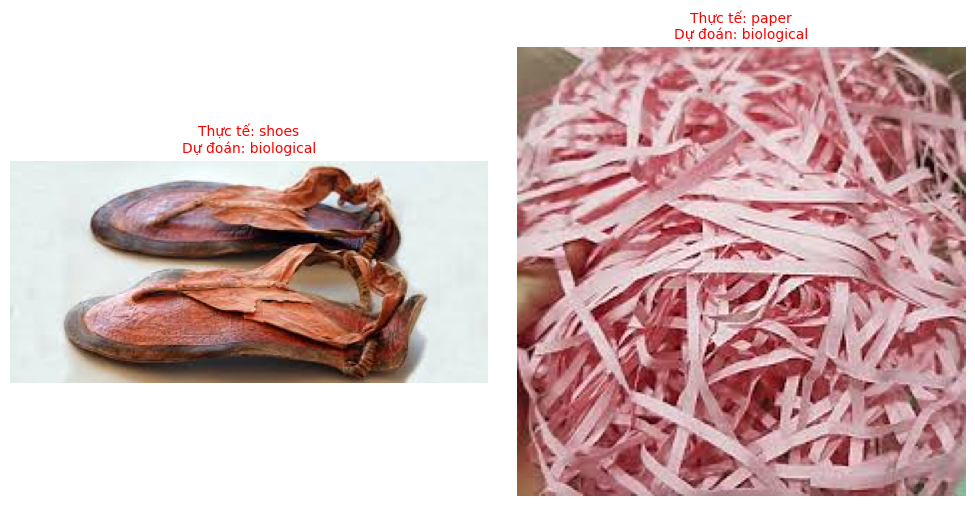

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

# 1. Tìm các chỉ mục (indices) nơi dự đoán SAI
misclassified_mask = (y_test != y_pred_test)
indices_in_test_set = np.where(misclassified_mask)[0]
num_misclassified = len(indices_in_test_set)

print(f"HIỂN THỊ 2 ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN TRÊN TẬP TEST (Tổng: {num_misclassified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_misclassified) 

# *** LOGIC CHỌN VÀ HIỂN THỊ ***

if num_misclassified > 0:
    # Lấy ngẫu nhiên 'num_to_display' chỉ mục
    random_misclassified_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False 
    )
    
    # Khởi tạo figure chỉ khi có mẫu để hiển thị
    fig, axes = plt.subplots(1, num_to_display, figsize=(10, 5))
    
    # Xử lý trường hợp chỉ hiển thị 1 ảnh
    if num_to_display == 1:
        axes = [axes] 

    for i in range(num_to_display):
        # Lấy chỉ mục đã chọn ngẫu nhiên
        test_idx = random_misclassified_indices[i] 
        
        # Lấy thông tin nhãn
        true_label = y_test[test_idx]
        pred_label = y_pred_test[test_idx]
        true_class_name = classes[true_label]
        predicted_class_name = classes[pred_label]
        
        # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
        image_path = paths_test[test_idx] 
        image = cv2.imread(image_path)
        
        if image is None:
            image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
            title_color = 'gray'
        else:
            # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            # Màu đỏ cho dự đoán sai
            title_color = 'red' 
        
        # Hiển thị ảnh
        axes[i].imshow(image_rgb)
        axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                          color=title_color, fontsize=10)
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()

else:
    print("Không có mẫu nào bị phân loại sai trong tập Test. (Chúc mừng! Hoặc kiểm tra lại dữ liệu). Không thể hiển thị hình ảnh.")

In [15]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import time

# BƯỚC 1: XÁC ĐỊNH LƯỚI THAM SỐ VÀ KHỞI TẠO GRID SEARCH
# Phạm vi các giá trị C và gamma cần thử nghiệm
param_grid = {
    'C': [0.1, 1, 10,100], # Thử nghiệm các giá trị C khác nhau
    'gamma': ['scale', 0.01, 0.1], # Thử nghiệm các giá trị gamma khác nhau
    'kernel': ['rbf'] 
}

base_svm = SVC(random_state=42)

print("BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN")
start_time = time.time()

# Grid Search sẽ tìm kiếm tham số tốt nhất qua 3-fold Cross-Validation trên X_train
grid_search = GridSearchCV(
    estimator=base_svm, 
    param_grid=param_grid, 
    cv=3, 
    verbose=2, 
    n_jobs=-1, # Sử dụng tất cả các lõi CPU
    scoring='accuracy' 
)

# Chạy tìm kiếm
grid_search.fit(X_train, y_train)

end_time = time.time()
print(f"\nThời gian chạy Grid Search: {end_time - start_time:.2f} giây")
print("="*60)

# BƯỚC 2: ĐÁNH GIÁ MÔ HÌNH TỐT NHẤT TRÊN TẬP TEST
# Lấy mô hình SVM tốt nhất đã được tối ưu
best_svm_model = grid_search.best_estimator_

print(f"Tham số TỐT NHẤT tìm được: {grid_search.best_params_}")
print(f"Độ chính xác TỐT NHẤT (Cross-Validation trên Train): {grid_search.best_score_:.4f}")

# Dự đoán trên tập Test BẰNG MÔ HÌNH TỐT NHẤT
y_pred_final = best_svm_model.predict(X_test)

# 1. Độ chính xác cuối cùng
final_accuracy = accuracy_score(y_test, y_pred_final)
print(f"Độ chính xác CUỐI CÙNG trên tập TEST: {final_accuracy:.4f}")

# 2. Báo cáo Phân loại cuối cùng
num_classes = len(classes)
all_labels = list(range(num_classes)) 

print("\nBáo cáo Phân loại CUỐI CÙNG (Classification Report trên Test):")
print(classification_report(y_test, y_pred_final, target_names=classes, labels=all_labels))

BẮT ĐẦU TỐI ƯU THAM SỐ SVM (GRID SEARCH CV) TRÊN TẬP TRAIN
Fitting 3 folds for each of 12 candidates, totalling 36 fits

Thời gian chạy Grid Search: 213.01 giây
Tham số TỐT NHẤT tìm được: {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
Độ chính xác TỐT NHẤT (Cross-Validation trên Train): 0.9843
Độ chính xác CUỐI CÙNG trên tập TEST: 0.9880

Báo cáo Phân loại CUỐI CÙNG (Classification Report trên Test):
              precision    recall  f1-score   support

       metal       0.98      0.97      0.97       154
 Plastic-bag       1.00      1.00      1.00       142
 white-glass       0.99      0.99      0.99       155
  biological       0.98      0.99      0.98       197
       paper       0.98      0.97      0.98       212
     battery       1.00      1.00      1.00       189
       trash       0.97      1.00      0.99       139
   cardboard       0.98      0.98      0.98       178
       shoes       0.98      0.98      0.98       396
     clothes       0.99      0.99      0.99      1065
     

MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST


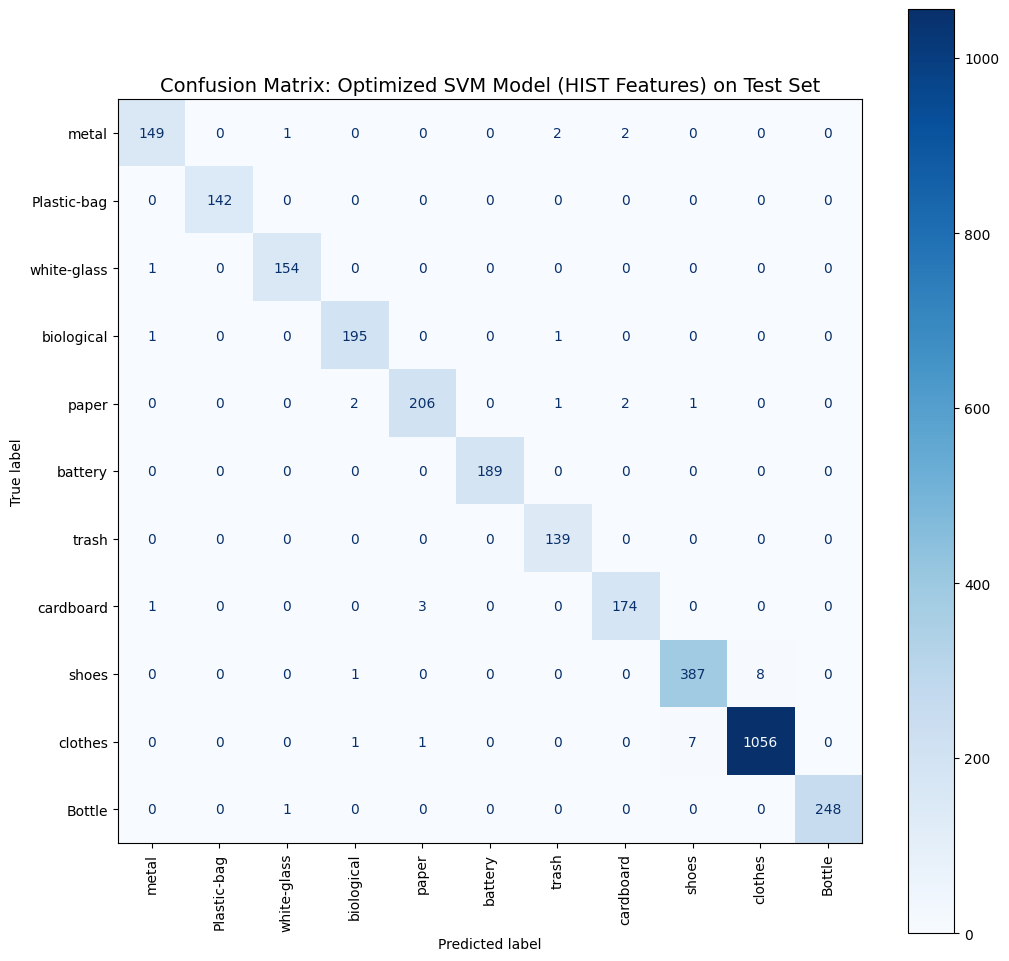


Ma trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: confusion_matrix_svm_optimized_hist_test.png


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Tính toán Ma trận nhầm lẫn
num_classes = len(classes)
all_labels = list(range(num_classes)) 

cm = confusion_matrix(
    y_test, 
    y_pred_final, 
    labels=all_labels # Đảm bảo ma trận có kích thước đầy đủ
)

# 2. Trực quan hóa Ma trận nhầm lẫn
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX) CHO MÔ HÌNH TỐI ƯU TRÊN TẬP TEST")

# Khởi tạo figure
fig, ax = plt.subplots(figsize=(12, 12)) 
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes) 

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix: Optimized SVM Model (HIST Features) on Test Set', fontsize=14)

# 3. Lưu hình ảnh
file_name = "confusion_matrix_svm_optimized_hist_test.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\nMa trận nhầm lẫn đã được tính toán và lưu thành công dưới dạng file: {file_name}")

In [17]:
import joblib
import os 
import time

timestamp = time.strftime("%Y%m%d_%H%M%S")
file_name = f"best_svm_clip_model_{timestamp}.joblib"

# BƯỚC 1: LƯU MÔ HÌNH
print(f"BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT")

try:
    joblib.dump(best_svm_model, file_name)
    
    print(f"Mô hình đã được lưu thành công tại: {os.path.abspath(file_name)}")
    print(f"Tham số: {best_svm_model.get_params()}")
except Exception as e:
    print(f"Lỗi khi lưu mô hình: {e}")

BẮT ĐẦU LƯU MÔ HÌNH SVM TỐT NHẤT
Mô hình đã được lưu thành công tại: /kaggle/working/best_svm_clip_model_20260119_140022.joblib
Tham số: {'C': 100, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 0.01, 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': 42, 'shrinking': True, 'tol': 0.001, 'verbose': False}
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  16.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=  43.9s
[CV] END ........................C=1, gamma=0.01, kernel=rbf; total time=   7.2s
[CV] END .........................C=1, gamma=0.1, kernel=rbf; total time=  49.4s
[CV] END ........................C=10, gamma=0.1, kernel=rbf; total time=  50.5s
[CV] END .....................C=0.1, gamma=scale, kernel=rbf; total time=  16.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=  16.9s
[CV] END ............